<a href="https://colab.research.google.com/github/murugisilvia294-rgb/-Do-G7-Climate-Commitments-Match-Reality-/blob/main/G7_Climate_Commitments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving g7_climate_long.csv to g7_climate_long.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats

Load data

In [4]:
df = pd.read_csv("g7_climate_long.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (70, 6)


,Country,Year,Emissions,Target,Gap,On_Track
0,United States,2015,5171,3300,1780,No
1,United States,2016,5109,3300,1780,No
2,United States,2017,5073,3300,1780,No
3,United States,2018,5146,3300,1780,No
4,United States,2019,5052,3300,1780,No


Correlation Matrix

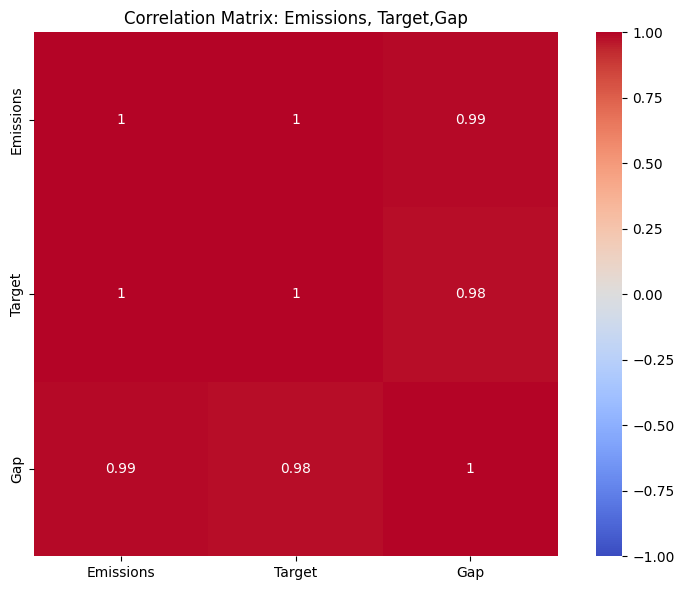

In [5]:
from numpy._core import numeric
numeric_cols = ['Emissions','Target','Gap']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1,vmax=1,square=True)
plt.title('Correlation Matrix: Emissions, Target,Gap')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()


Emissions Trend by Country

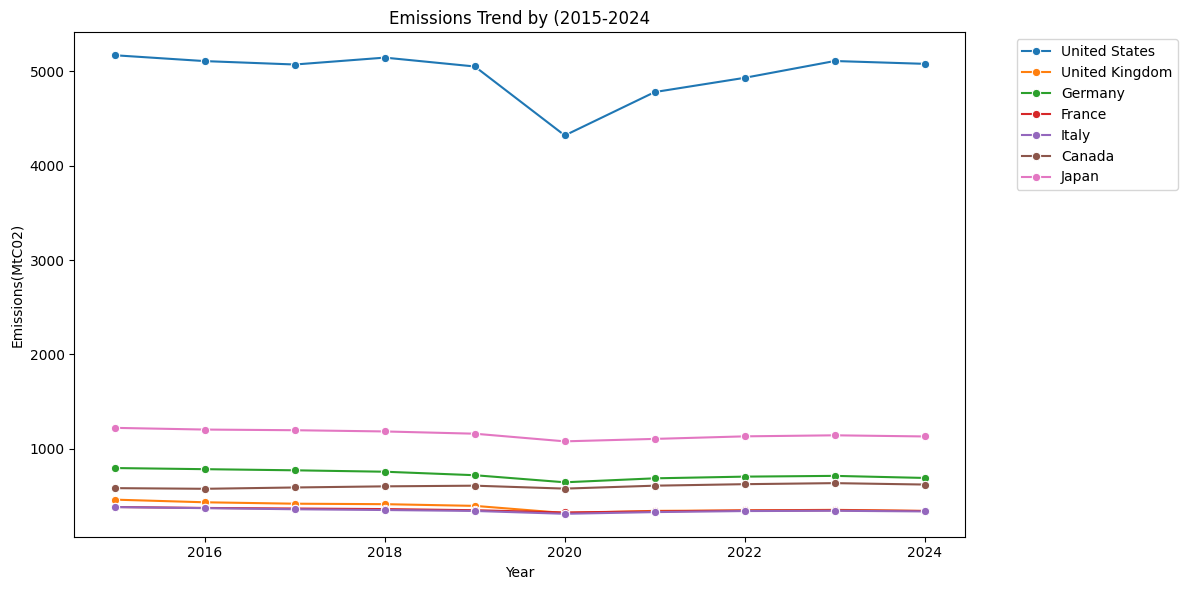

/tmp/ipykernel_3932/2624371634.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_2024, x='Country', y='Gap', palette='Reds_r')


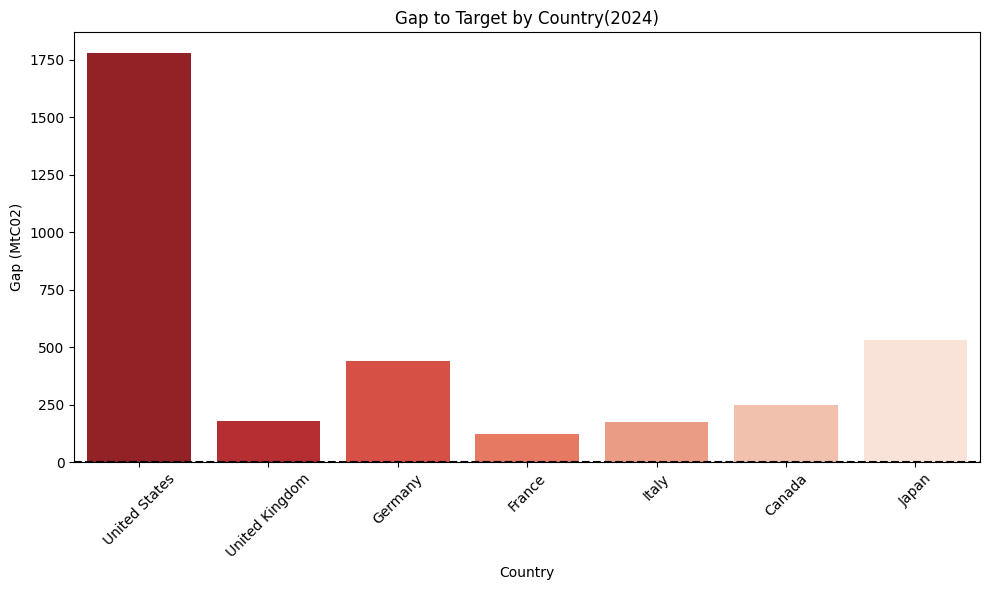

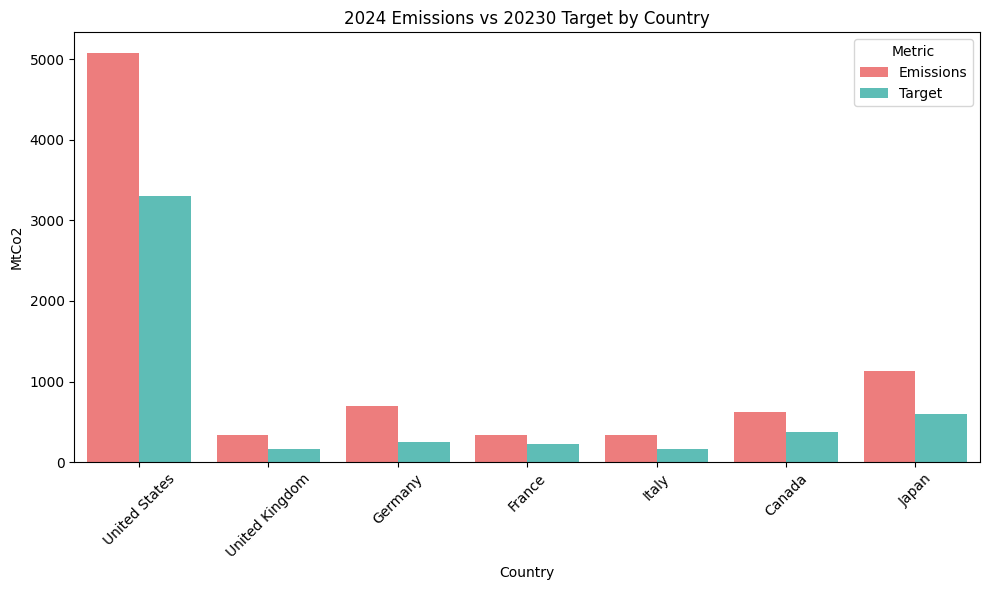


Regression Results(Emissions vs Year):
         Country      Slope     Intercept        R2
0  United States -20.260606  45893.793939  0.056676

Regression Results(Emissions vs Year):
          Country      Slope     Intercept        R2
0   United States -20.260606  45893.793939  0.056676
1  United Kingdom -13.842424  28335.975758  0.767992

Regression Results(Emissions vs Year):
          Country      Slope     Intercept        R2
0   United States -20.260606  45893.793939  0.056676
1  United Kingdom -13.842424  28335.975758  0.767992
2         Germany -12.496970  25963.630303  0.605355

Regression Results(Emissions vs Year):
          Country      Slope     Intercept        R2
0   United States -20.260606  45893.793939  0.056676
1  United Kingdom -13.842424  28335.975758  0.767992
2         Germany -12.496970  25963.630303  0.605355
3          France  -4.527273   9494.927273  0.598583

Regression Results(Emissions vs Year):
          Country      Slope     Intercept        R2
0   Uni

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Emissions', hue='Country',marker='o')
plt.title('Emissions Trend by (2015-2024')
plt.xlabel('Year')
plt.ylabel('Emissions(MtC02)')
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.savefig('emissions_trend.png')
plt.show()
# Gap to Target by Country(2024)

df_2024 =df[df['Year']==2024]
plt.figure(figsize=(10, 6))
sns.barplot(data=df_2024, x='Country', y='Gap', palette='Reds_r')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Gap to Target by Country(2024)')
plt.xlabel('Country')
plt.ylabel('Gap (MtC02)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('gap_to_target.png')
plt.show()

# Target vs Reality(2024)

df_melted = df_2024.melt(id_vars=['Country'], value_vars=['Emissions', 'Target'],var_name='Metric',value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Country', y='Value', hue='Metric', palette=['#FF6B6B','#4ECDC4'])
plt.title('2024 Emissions vs 20230 Target by Country')
plt.xlabel('Country')
plt.ylabel('MtCo2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('emissions_vs_target.png')
plt.show()

#Linear Regression (Emissions vs Year)

results = []
for country in df['Country'].unique():
  country_data = df[df['Country'] == country]
  x = country_data[['Year']]
  y = country_data['Emissions']
  model = LinearRegression().fit(x, y)
  slope = model.coef_[0]
  intercept = model.intercept_
  r2 = model.score(x, y)
  results.append({'Country':country, 'Slope': slope, 'Intercept': intercept,'R2': r2})
  results_df = pd.DataFrame(results)
  print("\nRegression Results(Emissions vs Year):")
  print(results_df)

K_Means Clustering (Emissions & Gap)

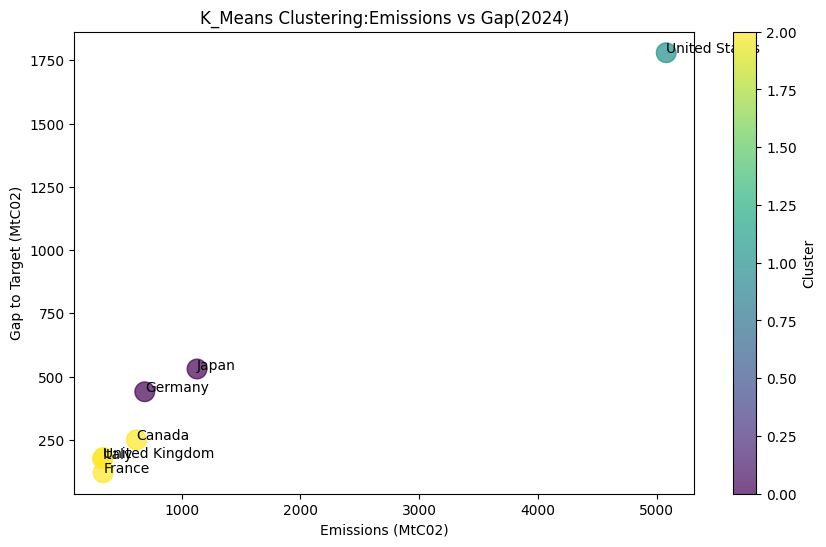

/tmp/ipykernel_3932/1238047058.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Country', y='Emissions', palette='Set2')


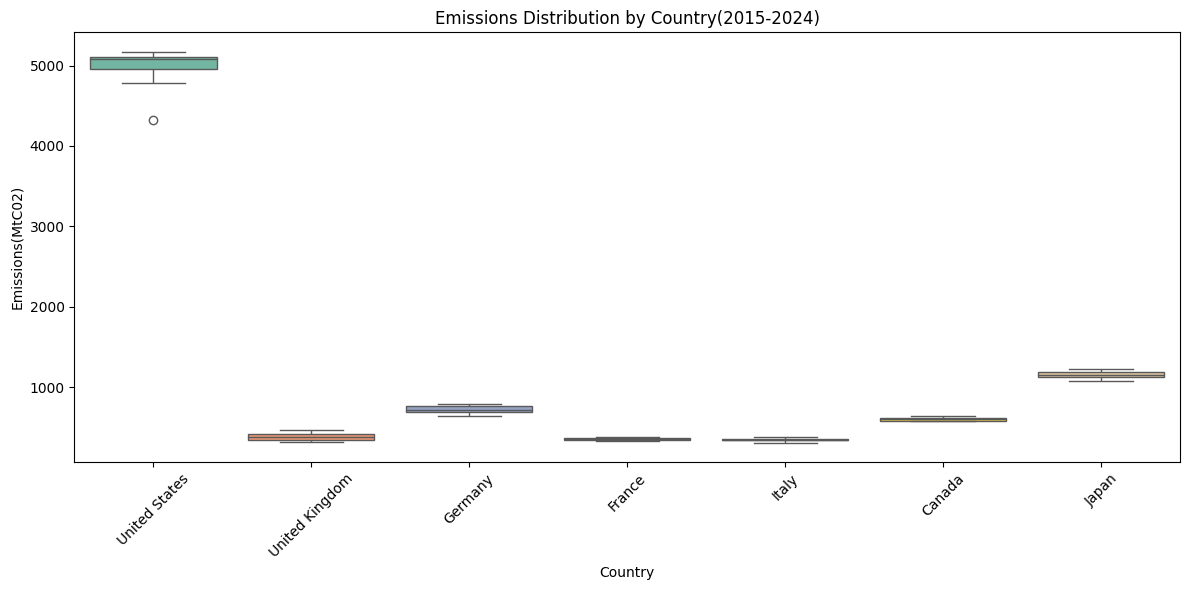


T-Test(2015 vs 2024): t = 0.07, p = 0.9450


In [7]:
df_2024_cluster = df_2024[['Emissions', 'Gap']].copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(df_2024_cluster)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_2024_cluster['Cluster'] = kmeans.fit_predict(scaled)

# Add the 'Cluster' column from df_2024_cluster back to df_2024
df_2024 = df_2024.merge(df_2024_cluster[['Cluster']], left_index=True, right_index=True, how='left')

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_2024['Emissions'],df_2024['Gap'], c=df_2024['Cluster'], cmap='viridis', s=200,alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('K_Means Clustering:Emissions vs Gap(2024)')
plt.xlabel('Emissions (MtC02)')
plt.ylabel('Gap to Target (MtC02)')
for i, country in enumerate(df_2024['Country']):
  plt.annotate(country, (df_2024['Emissions'].iloc[i], df_2024['Gap'].iloc[i]), fontsize=10)
plt.show()

# Boxplot : Emissions by Country (All Years)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Country', y='Emissions', palette='Set2')
plt.title('Emissions Distribution by Country(2015-2024)')
plt.xlabel('Country')
plt.ylabel('Emissions(MtC02)')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig('Emissions_boxplot.png')
plt.show()

# T_Test : 2015 vs 2024 Emissions

df_2015 = df[df['Year'] == 2015]
t_stat,p_val = stats.ttest_ind(df_2015['Emissions'], df_2024['Emissions'])
print(f"\nT-Test(2015 vs 2024): t = {t_stat:.2f}, p = {p_val:.4f}")

 # Export Results